开始综合分析市场结构...
正在识别波浪...
识别到 23 个波浪
正在计算趋势线...
正在检测交易繁忙区...
识别到 3 个交易繁忙区

           市场结构分析报告

📊 市场结构概览:
   • 价格波浪: 23 个
   • 推动波: 8 个
   • 调整波: 1 个
   • 趋势线: 4 条
   • 交易繁忙区: 3 个

🌊 推动波特征:
   • 平均幅度: 0.0797
   • 平均成交量比率: 1.15
🔄 调整波特征:
   • 平均幅度: 0.0259
   • 平均成交量比率: 0.78

⚡ 动量势能分析:
   • 当前综合势能: 0.2088
   • 当前势能水平: 中性
   • 当前势能趋势: 平稳
   • 交易信号: 中性

🎯 当前价格: 28.70
   ⚪ 中性建议 - 等待明确信号
正在生成可视化图表...


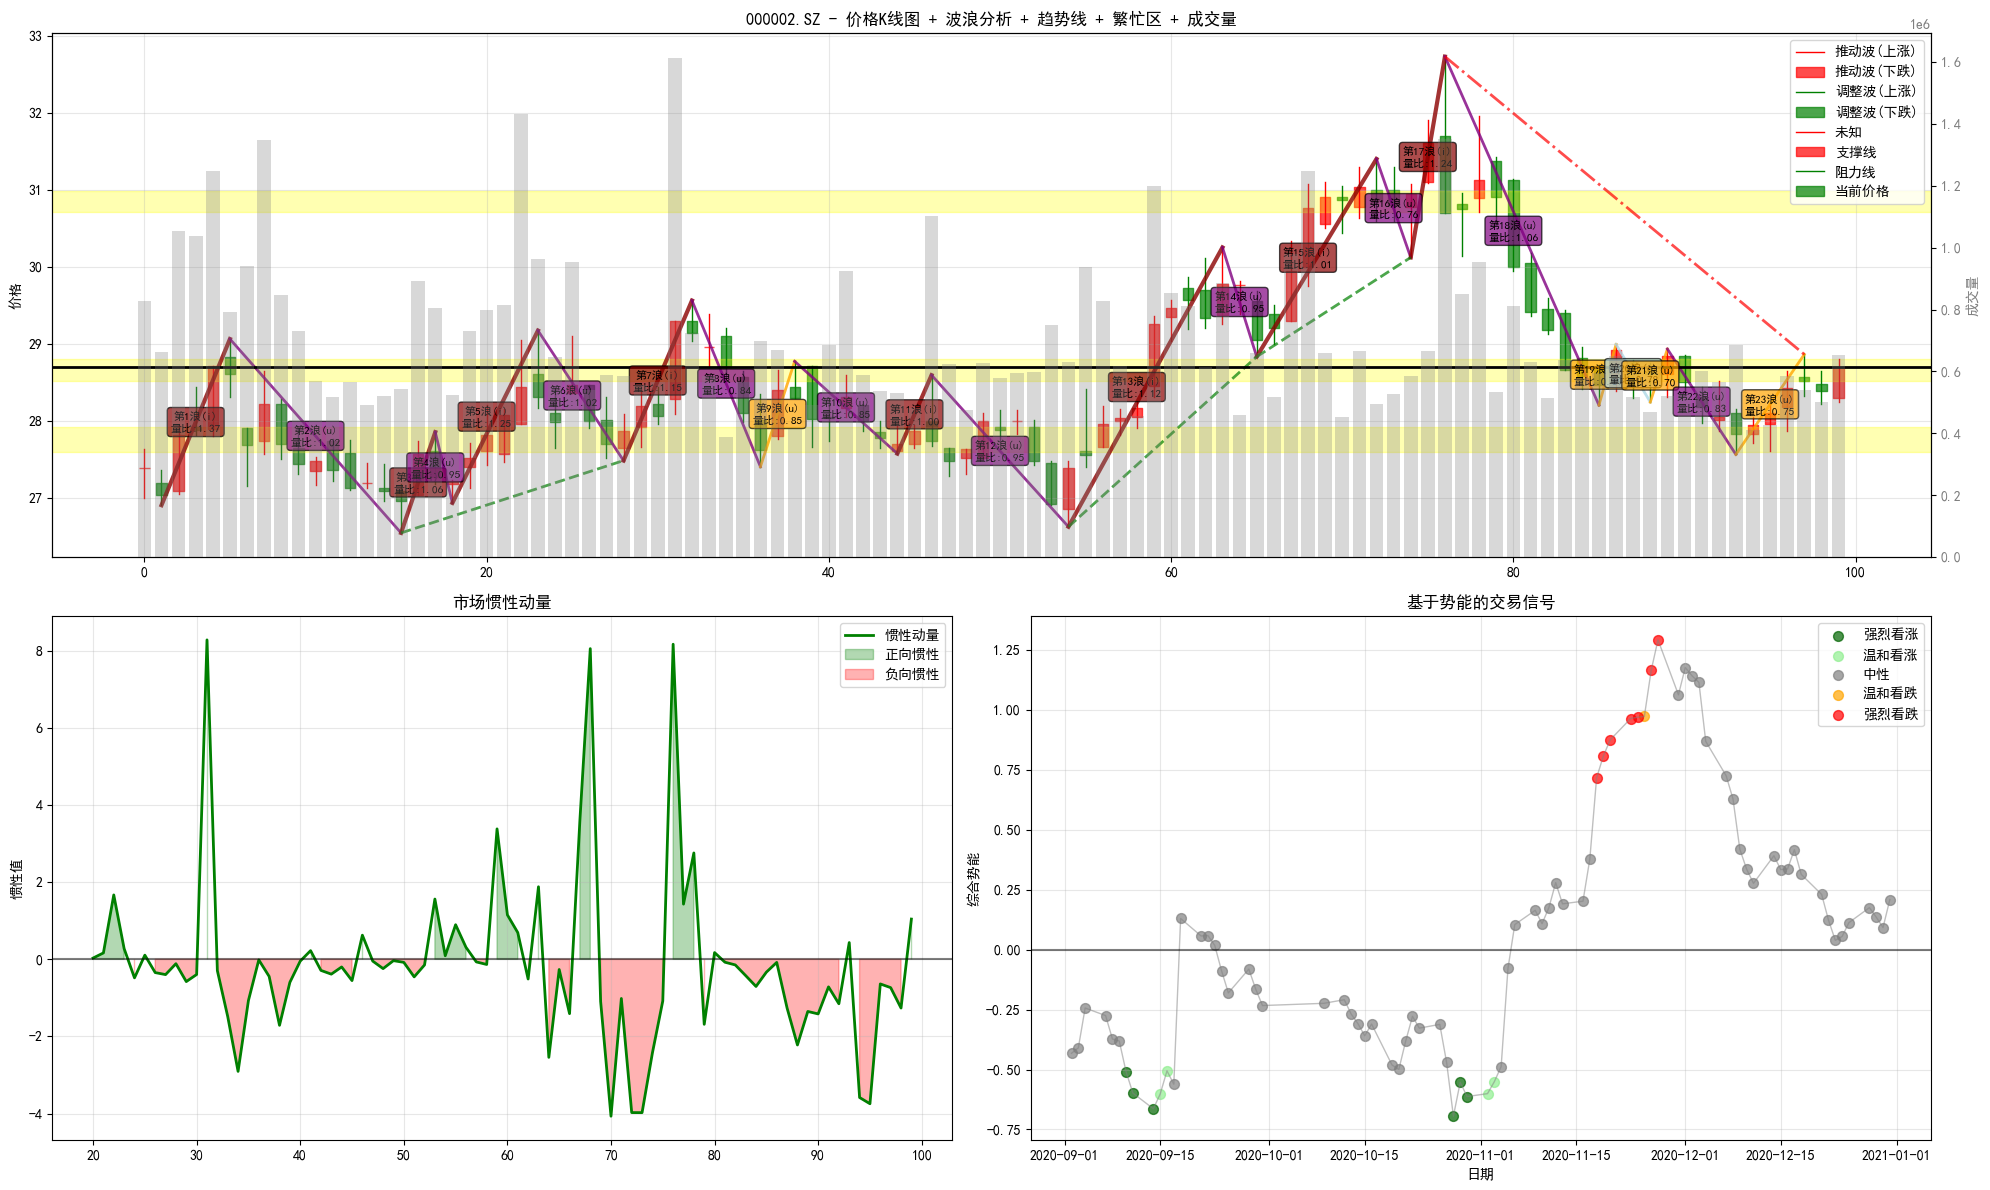

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

class MomentumAnalyzer:
    """动量分析器 - 负责动能势能计算"""
    def __init__(self, df):
        self.df = df.copy()
        self.calculate_technical_indicators()
        
    def calculate_technical_indicators(self):
        """计算技术指标用于势能评估"""
        # 基础价格变化
        self.df['price_change'] = self.df['close'].pct_change()
        self.df['log_return'] = np.log(self.df['close'] / self.df['close'].shift(1))
        
        # K线特征
        self.df['body_size'] = abs(self.df['close'] - self.df['open']) / self.df['open']
        self.df['total_range'] = (self.df['high'] - self.df['low']) / self.df['open']
        self.df['upper_shadow'] = (self.df['high'] - np.maximum(self.df['open'], self.df['close'])) / self.df['open']
        self.df['lower_shadow'] = (np.minimum(self.df['open'], self.df['close']) - self.df['low']) / self.df['open']
        
        # 价格位置特征
        self.df['price_position'] = (self.df['close'] - self.df['low']) / (self.df['high'] - self.df['low'])
        
        # 移动平均线
        self.df['ma5'] = self.df['close'].rolling(5).mean()
        self.df['ma20'] = self.df['close'].rolling(20).mean()
        
        # 成交量移动平均
        self.df['volume_ma5'] = self.df['volume'].rolling(5).mean()
        
        # 相对强弱
        self.df['relative_strength'] = (self.df['close'] - self.df['ma20']) / self.df['ma20']
    
    def calculate_potential_energy(self):
        """计算势能指标"""
        
        # 方法1: 动能势能模型
        # 动能 = 价格变化 × 成交量 (表示当前运动能量)
        self.df['kinetic_energy'] = self.df['log_return'] * self.df['volume']
        
        # 势能 = 价格位置 × 成交量 (表示潜在能量)
        # 在支撑位有向上势能，在阻力位有向下势能
        self.df['potential_energy'] = (self.df['price_position'] - 0.5) * self.df['volume'] * 2
        
        # 总机械能 = 动能 + 势能
        self.df['total_mechanical_energy'] = self.df['kinetic_energy'] + self.df['potential_energy']
        self.df['cumulative_mechanical_energy'] = self.df['total_mechanical_energy'].cumsum()
        
        # 方法2: 压力-支撑势能模型
        # 基于K线形态的压力支撑判断
        def calculate_pressure_support(row):
            # 上影线长表示压力大，下影线长表示支撑强
            pressure = row['upper_shadow'] * row['volume']
            support = row['lower_shadow'] * row['volume']
            
            # 实体方向加强压力支撑效果
            if row['close'] > row['open']:
                # 阳线：支撑有效，压力被突破
                net_effect = support - pressure * 0.5
            else:
                # 阴线：压力有效，支撑被突破
                net_effect = pressure - support * 0.5
                
            return net_effect
        
        self.df['pressure_support_energy'] = self.df.apply(calculate_pressure_support, axis=1)
        self.df['cumulative_pressure_support'] = self.df['pressure_support_energy'].cumsum()
        
        # 方法3: 趋势势能模型
        # 基于移动平均线的趋势强度
        self.df['trend_strength'] = (self.df['ma5'] - self.df['ma20']) / self.df['ma20'] * 100
        self.df['volume_trend_energy'] = self.df['trend_strength'] * self.df['volume'] / self.df['volume_ma5']
        self.df['cumulative_trend_energy'] = self.df['volume_trend_energy'].cumsum()
        
        # 方法4: 突破势能模型
        # 识别关键位置的突破能量
        self.df['breakout_energy'] = 0
        for i in range(1, len(self.df)):
            current = self.df.iloc[i]
            prev = self.df.iloc[i-1]
            
            # 突破前高
            if current['close'] > prev['high'] and current['volume'] > prev['volume']:
                self.df.iloc[i, self.df.columns.get_loc('breakout_energy')] = \
                    current['log_return'] * current['volume'] * 2
            # 跌破前低
            elif current['close'] < prev['low'] and current['volume'] > prev['volume']:
                self.df.iloc[i, self.df.columns.get_loc('breakout_energy')] = \
                    current['log_return'] * current['volume'] * 2
            # 普通情况
            else:
                self.df.iloc[i, self.df.columns.get_loc('breakout_energy')] = \
                    current['log_return'] * current['volume']
        
        self.df['cumulative_breakout_energy'] = self.df['breakout_energy'].cumsum()
        
        # 综合势能指标（加权组合）
        weights = {
            'mechanical': 0.3,
            'pressure_support': 0.25,
            'trend': 0.25,
            'breakout': 0.2
        }
        
        # 标准化各能量指标
        for col in ['cumulative_mechanical_energy', 'cumulative_pressure_support', 
                   'cumulative_trend_energy', 'cumulative_breakout_energy']:
            if self.df[col].std() > 0:
                self.df[f'normalized_{col}'] = (self.df[col] - self.df[col].mean()) / self.df[col].std()
            else:
                self.df[f'normalized_{col}'] = 0
        
        # 计算综合势能
        self.df['comprehensive_energy'] = (
            weights['mechanical'] * self.df['normalized_cumulative_mechanical_energy'] +
            weights['pressure_support'] * self.df['normalized_cumulative_pressure_support'] +
            weights['trend'] * self.df['normalized_cumulative_trend_energy'] +
            weights['breakout'] * self.df['normalized_cumulative_breakout_energy']
        )
        
        # 势能变化率（势能的动能）
        self.df['energy_momentum'] = self.df['comprehensive_energy'].diff(3)  # 3期变化
    
    def generate_signals(self):
        """基于势能生成交易信号 - 修复数据类型问题"""
        # 势能水平信号
        self.df['energy_level'] = pd.cut(
            self.df['comprehensive_energy'], 
            bins=[-np.inf, -1, -0.5, 0.5, 1, np.inf],
            labels=['极低', '较低', '中性', '较高', '极高']
        )
        
        # 势能变化信号 - 修复数据类型问题
        momentum_conditions = [
            self.df['energy_momentum'] > 0.1,
            self.df['energy_momentum'] < -0.1
        ]
        momentum_choices = ['加速上升', '加速下降']
        # 确保默认值也是字符串类型
        self.df['energy_trend'] = np.select(momentum_conditions, momentum_choices, default='平稳')
        
        # 信号逻辑 - 修复数据类型问题
        conditions = [
            # 高势能 + 加速上升 → 强烈看跌（过热，可能反转）
            (self.df['energy_level'].isin(['极高', '较高'])) & (self.df['energy_trend'] == '加速上升'),
            # 低势能 + 加速下降 → 强烈看涨（超卖，可能反弹）
            (self.df['energy_level'].isin(['极低', '较低'])) & (self.df['energy_trend'] == '加速下降'),
            # 高势能 + 平稳 → 温和看跌
            (self.df['energy_level'].isin(['较高'])) & (self.df['energy_trend'] == '平稳'),
            # 低势能 + 平稳 → 温和看涨
            (self.df['energy_level'].isin(['较低'])) & (self.df['energy_trend'] == '平稳')
        ]
        choices = ['强烈看跌', '强烈看涨', '温和看跌', '温和看涨']
        # 确保所有选择都是字符串类型
        self.df['trading_signal'] = np.select(conditions, choices, default='中性')

class WaveAnalyzer:
    """波浪分析器 - 负责波浪识别和分析"""
    def __init__(self, df):
        self.df = df.copy()
        self.waves = []
        self.trend_lines = []
    
    def detect_high_low_points(self, window=2):
        """可靠检测高点和低点极点"""
        if 'high' not in self.df.columns or 'low' not in self.df.columns:
            raise ValueError("DataFrame必须包含'high'和'low'列")
        
        high_prices = self.df['high'].values
        low_prices = self.df['low'].values
        
        # 检测高点（局部最大值）
        high_indices = argrelextrema(high_prices, np.greater, order=window)[0]
        # 检测低点（局部最小值）
        low_indices = argrelextrema(low_prices, np.less, order=window)[0]
        
        # 检查窗口的第一个和最后一个点是否是极值
        if len(self.df) > 0:
            if len(high_prices) > 0 and high_prices[0] >= max(high_prices[:min(3, len(high_prices))]):
                if 0 not in high_indices:
                    high_indices = np.insert(high_indices, 0, 0)
            
            if len(low_prices) > 0 and low_prices[0] <= min(low_prices[:min(3, len(low_prices))]):
                if 0 not in low_indices:
                    low_indices = np.insert(low_indices, 0, 0)
            
            if len(high_prices) > 0 and high_prices[-1] >= max(high_prices[-min(3, len(high_prices)):]):
                if len(high_prices)-1 not in high_indices:
                    high_indices = np.append(high_indices, len(high_prices)-1)
            
            if len(low_prices) > 0 and low_prices[-1] <= min(low_prices[-min(3, len(low_prices)):]):
                if len(low_prices)-1 not in low_indices:
                    low_indices = np.append(low_indices, len(low_prices)-1)
        
        # 创建标记列
        df_with_extremes = self.df.copy()
        df_with_extremes['is_high'] = False
        df_with_extremes['is_low'] = False
        df_with_extremes['is_extreme_high'] = False
        df_with_extremes['is_extreme_low'] = False
        
        # 标记高点和低点
        df_with_extremes.iloc[high_indices, df_with_extremes.columns.get_loc('is_high')] = True
        df_with_extremes.iloc[low_indices, df_with_extremes.columns.get_loc('is_low')] = True
        
        # 检测极高点
        if len(high_indices) >= 3:
            for i in range(1, len(high_indices) - 1):
                prev_idx = high_indices[i-1]
                current_idx = high_indices[i]
                next_idx = high_indices[i+1]
                
                current_high = high_prices[current_idx]
                prev_high = high_prices[prev_idx]
                next_high = high_prices[next_idx]
                
                if current_high > prev_high and current_high > next_high:
                    df_with_extremes.iloc[current_idx, df_with_extremes.columns.get_loc('is_extreme_high')] = True
        
        # 检测极低点
        if len(low_indices) >= 3:
            for i in range(1, len(low_indices) - 1):
                prev_idx = low_indices[i-1]
                current_idx = low_indices[i]
                next_idx = low_indices[i+1]
                
                current_low = low_prices[current_idx]
                prev_low = low_prices[prev_idx]
                next_low = low_prices[next_idx]
                
                if current_low < prev_low and current_low < next_low:
                    df_with_extremes.iloc[current_idx, df_with_extremes.columns.get_loc('is_extreme_low')] = True
        
        return df_with_extremes
    
    def merge_nearby_points(self, points, centers, price_range, merge_threshold=0.05):
        """合并中枢附近的高低点"""
        if not points or not centers:
            return points
        
        merge_distance = price_range * merge_threshold
        
        merged_points = []
        i = 0
        
        while i < len(points):
            current_point = points[i]
            current_idx, current_type, current_price = current_point
            
            near_center = False
            for center in centers:
                if abs(current_price - center) <= merge_distance:
                    near_center = True
                    break
            
            if near_center:
                group = [current_point]
                j = i + 1
                
                while j < len(points):
                    next_point = points[j]
                    next_idx, next_type, next_price = next_point
                    
                    next_near_center = False
                    for center in centers:
                        if abs(next_price - center) <= merge_distance:
                            next_near_center = True
                            break
                    
                    if next_near_center and next_type == current_type:
                        group.append(next_point)
                        j += 1
                    else:
                        break
                
                if len(group) > 1:
                    merged_points.append(group[0])
                    merged_points.append(group[-1])
                else:
                    merged_points.append(current_point)
                
                i = j
            else:
                merged_points.append(current_point)
                i += 1
        
        return merged_points
    
    def mark_extremes_in_merged_points(self, merged_points, df_with_extremes):
        """在合并后的点中标记极值"""
        if len(merged_points) == 0:
            return

        # 确保有极值列
        if 'is_extreme_high' not in df_with_extremes.columns:
            df_with_extremes['is_extreme_high'] = False
        if 'is_extreme_low' not in df_with_extremes.columns:
            df_with_extremes['is_extreme_low'] = False

        i = 0
        n = len(merged_points)
        
        while i < n:
            curr_type = merged_points[i][1]
            segment = []
            j = i
            
            # 收集连续同类型点
            while j < n and merged_points[j][1] == curr_type:
                segment.append(merged_points[j])
                j += 1
            
            # 检查这段是否已有极值
            has_extreme = False
            for idx, pt_type, price in segment:
                if pt_type == 'high':
                    if df_with_extremes.iloc[idx]['is_extreme_high']:
                        has_extreme = True
                        break
                else:
                    if df_with_extremes.iloc[idx]['is_extreme_low']:
                        has_extreme = True
                        break
            
            # 如果没有极值，且长度 >= 2，标记最值
            if not has_extreme and len(segment) >= 2:
                if curr_type == 'high':
                    # 找最高价
                    max_pt = max(segment, key=lambda x: x[2])
                    df_with_extremes.iloc[max_pt[0], df_with_extremes.columns.get_loc('is_extreme_high')] = True
                else:  # low
                    min_pt = min(segment, key=lambda x: x[2])
                    df_with_extremes.iloc[min_pt[0], df_with_extremes.columns.get_loc('is_extreme_low')] = True
            
            i = j  # 跳到下一段
    
    def simple_connect_points(self, points, df_with_extremes):
        """波浪连接：从当前点出发，向后找到下一个反向类型段"""
        if len(points) < 2:
            return []

        waves = []
        i = 0
        n = len(points)

        while i < n:
            curr_idx, curr_type, curr_price = points[i]
            target_type = 'low' if curr_type == 'high' else 'high'

            # Step 1: 找到从 i+1 开始的第一个 target_type 段（连续的）
            j = i + 1
            # 跳过非 target_type 的点
            while j < n and points[j][1] != target_type:
                j += 1
            
            if j >= n:
                break  # 没有目标类型了

            # Step 2: 收集整个连续的 target_type 段
            segment_start = j
            while j < n and points[j][1] == target_type:
                j += 1
            segment_end = j  # segment is [segment_start, segment_end)

            target_segment = points[segment_start:segment_end]

            # Step 3: 在 segment 中找第一个极值点
            target_point = None
            for pt in target_segment:
                pt_idx, pt_type, pt_price = pt
                is_extreme = False
                if pt_type == 'high':
                    is_extreme = df_with_extremes.iloc[pt_idx]['is_extreme_high']
                else:
                    is_extreme = df_with_extremes.iloc[pt_idx]['is_extreme_low']
                
                if is_extreme:
                    target_point = pt
                    break
            
            # 如果没极值，取 segment 最后一个点
            if target_point is None:
                target_point = target_segment[-1]

            # Step 4: 创建波浪
            if curr_type == 'low':
                wave = {
                    'start_idx': curr_idx,
                    'end_idx': target_point[0],
                    'start_type': 'low',
                    'end_type': 'high',
                    'direction': 'up',
                    'start_price': curr_price,
                    'end_price': target_point[2],
                    'height': target_point[2] - curr_price
                }
            else:
                wave = {
                    'start_idx': curr_idx,
                    'end_idx': target_point[0],
                    'start_type': 'high',
                    'end_type': 'low',
                    'direction': 'down',
                    'start_price': curr_price,
                    'end_price': target_point[2],
                    'height': curr_price - target_point[2]
                }
            waves.append(wave)

            # Step 5: 找到 target_point 在 points 中的索引，作为下一次起点
            next_i = segment_start
            while next_i < segment_end and points[next_i] != target_point:
                next_i += 1
            
            if next_i >= segment_end:
                next_i = segment_end - 1  # fallback to last

            i = next_i  # 从目标点继续

        return waves
    
    def identify_waves_from_points(self, points, df_with_extremes):
        """从高低点序列识别波浪"""
        if len(points) < 2:
            return []
        
        # 使用简单连接方法
        waves = self.simple_connect_points(points, df_with_extremes)
        
        # 为波浪编号
        for i, wave in enumerate(waves):
            wave['wave_number'] = i + 1
        
        return waves
    
    def identify_waves(self, centers):
        """识别波浪"""
        print("正在识别波浪...")
        
        # 使用改进的高低点检测
        df_with_extremes = self.detect_high_low_points(window=2)
        
        # 创建高低点序列
        points = []
        for i in range(len(df_with_extremes)):
            if df_with_extremes.iloc[i]['is_high']:
                points.append((i, 'high', self.df['high'].iloc[i]))
            if df_with_extremes.iloc[i]['is_low']:
                points.append((i, 'low', self.df['low'].iloc[i]))
        
        # 按索引排序
        points.sort(key=lambda x: x[0])
        
        if len(points) < 2:
            self.waves = []
            return []
        
        # 计算价格范围用于合并
        price_range = self.df['high'].max() - self.df['low'].min()
        
        # 合并附近点
        merged_points = self.merge_nearby_points(points, centers, price_range)
        
        # 标记极值点
        self.mark_extremes_in_merged_points(merged_points, df_with_extremes)
        
        # 识别波浪
        waves = self.identify_waves_from_points(merged_points, df_with_extremes)
        
        # 转换为标准格式并计算成交量比率
        formatted_waves = []
        for wave in waves:
            # 计算成交量比率
            volume_ratio = np.mean(self.df['volume'].iloc[wave['start_idx']:wave['end_idx']+1]) / np.mean(self.df['volume'])
            
            formatted_wave = {
                'start_idx': wave['start_idx'],
                'end_idx': wave['end_idx'],
                'start_price': wave['start_price'],
                'end_price': wave['end_price'],
                'type': 'up' if wave['direction'] == 'up' else 'down',
                'amplitude': abs(wave['end_price'] - wave['start_price']) / wave['start_price'],
                'duration': wave['end_idx'] - wave['start_idx'],
                'slope': (wave['end_price'] - wave['start_price']) / (wave['end_idx'] - wave['start_idx']) if (wave['end_idx'] - wave['start_idx']) > 0 else 0,
                'volume_ratio': volume_ratio,
                'wave_type': 'unknown'  # 将在后续步骤中识别
            }
            formatted_waves.append(formatted_wave)
        
        # 识别推动波和调整波
        formatted_waves = self._identify_wave_types(formatted_waves)
        
        self.waves = formatted_waves
        print(f"识别到 {len(formatted_waves)} 个波浪")
        return formatted_waves
    
    def _identify_wave_types(self, waves):
        """识别推动波和调整波"""
        if len(waves) < 3:
            for wave in waves:
                wave['wave_type'] = 'unknown'
            return waves
        
        # 计算整体趋势方向
        total_up_amplitude = sum([w['amplitude'] for w in waves if w['type'] == 'up'])
        total_down_amplitude = sum([w['amplitude'] for w in waves if w['type'] == 'down'])
        
        overall_trend = 'up' if total_up_amplitude > total_down_amplitude else 'down'
        
        # 识别波浪类型
        for i, wave in enumerate(waves):
            # 推动波特征：与趋势同向，幅度大，成交量放大
            # 调整波特征：与趋势反向，幅度小，成交量缩小
            
            if overall_trend == 'up':  # 上升趋势
                if wave['type'] == 'up' and wave['amplitude'] > 0.02 and wave['volume_ratio'] > 0.9:
                    wave['wave_type'] = 'impulse'  # 推动波
                elif wave['type'] == 'down' and wave['amplitude'] < 0.03 and wave['volume_ratio'] < 1.1:
                    wave['wave_type'] = 'correction'  # 调整波
                else:
                    wave['wave_type'] = 'unknown'
            else:  # 下降趋势
                if wave['type'] == 'down' and wave['amplitude'] > 0.02 and wave['volume_ratio'] > 0.9:
                    wave['wave_type'] = 'impulse'  # 推动波
                elif wave['type'] == 'up' and wave['amplitude'] < 0.03 and wave['volume_ratio'] < 1.1:
                    wave['wave_type'] = 'correction'  # 调整波
                else:
                    wave['wave_type'] = 'unknown'
        
        return waves
    
    def calculate_trend_lines(self):
        """计算趋势线"""
        print("正在计算趋势线...")
        
        highs = self.df['high'].values
        lows = self.df['low'].values
        
        # 寻找显著的高点和低点
        high_indices = argrelextrema(highs, np.greater, order=5)[0]
        low_indices = argrelextrema(lows, np.less, order=5)[0]
        
        trend_lines = []
        
        # 上升趋势线（连接连续的低点）
        if len(low_indices) >= 2:
            for i in range(len(low_indices)-1):
                start_idx = low_indices[i]
                end_idx = low_indices[i+1]
                start_price = lows[start_idx]
                end_price = lows[end_idx]
                
                if end_price > start_price:  # 上升趋势
                    slope = (end_price - start_price) / (end_idx - start_idx)
                    trend_lines.append({
                        'type': 'support',
                        'start_idx': start_idx,
                        'end_idx': end_idx,
                        'start_price': start_price,
                        'end_price': end_price,
                        'slope': slope
                    })
        
        # 下降趋势线（连接连续的高点）
        if len(high_indices) >= 2:
            for i in range(len(high_indices)-1):
                start_idx = high_indices[i]
                end_idx = high_indices[i+1]
                start_price = highs[start_idx]
                end_price = highs[end_idx]
                
                if end_price < start_price:  # 下降趋势
                    slope = (end_price - start_price) / (end_idx - start_idx)
                    trend_lines.append({
                        'type': 'resistance',
                        'start_idx': start_idx,
                        'end_idx': end_idx,
                        'start_price': start_price,
                        'end_price': end_price,
                        'slope': slope
                    })
        
        self.trend_lines = trend_lines
        return trend_lines

class KLineCenterAnalyzer:
    """K线中枢分析器 - 负责繁忙区和中枢分析"""
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation
        self.max_zone_width_ratio = max_zone_width_ratio
        self.entity_size_threshold = entity_size_threshold
        self.busy_zones = []
    
    def is_bullish(self, open_price, close_price):
        """判断是否为阳线"""
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        """计算影线比例"""
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        """寻找K线反转点"""
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            # 检查颜色反转
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            # 颜色反转点
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            # 检查影线反转
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            # 影线比例超过阈值，可能是反转点
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        """寻找成交量极值点对应的K线价格"""
        volumes = df['volume'].values
        closes = df['close'].values
        
        # 寻找成交量局部高点
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        
        volume_points = []
        for idx in volume_high_idx:
            volume_points.append(('volume_price', idx, closes[idx]))
        
        return volume_points
    
    def cluster_prices(self, points, n_clusters=3):
        """对价格点进行聚类，返回聚类中心"""
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        """找出中枢水平线"""
        reversal_points = self.find_reversal_points(df)
        volume_points = self.find_volume_price_points(df)
        
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        center_lines = self.cluster_prices(all_points, 3)
        
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        """计算中枢区域，确保不重叠"""
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)
        
        for center_line in center_lines:
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                min_zone_height = price_range * 0.005
                if zone_high - zone_low < min_zone_height:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                if zone_high - zone_low > max_zone_width:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        # 发现重叠，合并区域
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        # 确保区域之间有最小分离距离，防止重叠
        center_zones.sort(key=lambda x: x[0])
        
        non_overlapping_zones = []
        for zone in center_zones:
            center_line, zone_low, zone_high, count = zone
            
            if not non_overlapping_zones:
                non_overlapping_zones.append(zone)
                continue
                
            # 检查是否与已有区域重叠
            overlaps = False
            for existing_zone in non_overlapping_zones:
                existing_center, existing_low, existing_high, existing_count = existing_zone
                
                if not (zone_high < existing_low or zone_low > existing_high):
                    # 有重叠，跳过这个区域
                    overlaps = True
                    break
            
            if not overlaps:
                non_overlapping_zones.append(zone)
        
        # 按中心线排序
        non_overlapping_zones.sort(key=lambda x: x[0])
        
        return non_overlapping_zones
    
    def detect_busy_zones(self, df):
        """检测繁忙区"""
        print("正在检测交易繁忙区...")
        
        # 使用K线中枢分析器找到中枢区域
        center_lines, reversal_points, volume_points = self.find_centers(df)
        center_zones = self.calculate_center_zones(df, center_lines)
        
        # 转换为繁忙区格式
        busy_zones = []
        volumes = df['volume'].values
        avg_volume = np.mean(volumes)
        
        for center_line, zone_low, zone_high, count in center_zones:
            # 找到穿过该中枢区域的K线时间范围
            start_idx = None
            end_idx = None
            
            for i in range(len(df)):
                if df['low'].iloc[i] <= zone_high and df['high'].iloc[i] >= zone_low:
                    if start_idx is None:
                        start_idx = i
                    end_idx = i
            
            if start_idx is not None and end_idx is not None:
                # 计算该区域的成交量密度
                zone_volumes = volumes[start_idx:end_idx+1]
                volume_density = np.mean(zone_volumes) / avg_volume
                
                zone = {
                    'price_range': (zone_low, zone_high),
                    'center_price': center_line,
                    'time_range': (start_idx, end_idx),
                    'volume_density': volume_density,
                    'data_points': count,
                    'volatility': (zone_high - zone_low) / center_line
                }
                busy_zones.append(zone)
        
        self.busy_zones = busy_zones
        print(f"识别到 {len(busy_zones)} 个交易繁忙区")
        return busy_zones

class MarketAnalyzer:
    """市场分析器 - 综合调用各分析器生成最终结果"""
    def __init__(self, df):
        self.df = df.copy()
        self.momentum_analyzer = MomentumAnalyzer(df)
        self.wave_analyzer = WaveAnalyzer(df)
        self.center_analyzer = KLineCenterAnalyzer(window=3)
        
        # 分析结果
        self.waves = []
        self.trend_lines = []
        self.busy_zones = []
        self.momentum_data = None
    
    def analyze_market_structure(self):
        """综合分析市场结构"""
        print("开始综合分析市场结构...")
        
        # 执行所有分析步骤
        self._analyze_waves()
        self._analyze_busy_zones()
        self._analyze_momentum()
        
        # 生成综合报告
        self._generate_analysis_report()
        
        return {
            'waves': self.waves,
            'trend_lines': self.trend_lines,
            'busy_zones': self.busy_zones,
            'momentum': self.momentum_data
        }
    
    def _analyze_waves(self):
        """分析波浪"""
        # 先找到中枢
        center_lines, _, _ = self.center_analyzer.find_centers(self.df)
        # 识别波浪
        self.waves = self.wave_analyzer.identify_waves(center_lines)
        # 计算趋势线
        self.trend_lines = self.wave_analyzer.calculate_trend_lines()
    
    def _analyze_busy_zones(self):
        """分析繁忙区"""
        self.busy_zones = self.center_analyzer.detect_busy_zones(self.df)
    
    def _analyze_momentum(self):
        """分析动量"""
        self.momentum_analyzer.calculate_potential_energy()
        self.momentum_analyzer.generate_signals()
        self.momentum_data = self.momentum_analyzer.df[['comprehensive_energy', 'energy_level', 'energy_trend', 'trading_signal']]
    
    def _generate_analysis_report(self):
        """生成分析报告"""
        print("\n" + "="*60)
        print("           市场结构分析报告")
        print("="*60)
        
        current_price = self.df['close'].iloc[-1]
        
        print(f"\n📊 市场结构概览:")
        print(f"   • 价格波浪: {len(self.waves)} 个")
        print(f"   • 推动波: {len([w for w in self.waves if w.get('wave_type') == 'impulse'])} 个")
        print(f"   • 调整波: {len([w for w in self.waves if w.get('wave_type') == 'correction'])} 个")
        print(f"   • 趋势线: {len(self.trend_lines)} 条")
        print(f"   • 交易繁忙区: {len(self.busy_zones)} 个")
        
        # 波浪分析
        if self.waves:
            impulse_waves = [w for w in self.waves if w.get('wave_type') == 'impulse']
            correction_waves = [w for w in self.waves if w.get('wave_type') == 'correction']
            
            if impulse_waves:
                avg_impulse_amplitude = np.mean([w['amplitude'] for w in impulse_waves])
                avg_impulse_volume = np.mean([w['volume_ratio'] for w in impulse_waves])
                print(f"\n🌊 推动波特征:")
                print(f"   • 平均幅度: {avg_impulse_amplitude:.4f}")
                print(f"   • 平均成交量比率: {avg_impulse_volume:.2f}")
            
            if correction_waves:
                avg_correction_amplitude = np.mean([w['amplitude'] for w in correction_waves])
                avg_correction_volume = np.mean([w['volume_ratio'] for w in correction_waves])
                print(f"🔄 调整波特征:")
                print(f"   • 平均幅度: {avg_correction_amplitude:.4f}")
                print(f"   • 平均成交量比率: {avg_correction_volume:.2f}")
        
        # 动量势能分析
        if self.momentum_data is not None:
            current_energy = self.momentum_data['comprehensive_energy'].iloc[-1] if not pd.isna(self.momentum_data['comprehensive_energy'].iloc[-1]) else 0
            print(f"\n⚡ 动量势能分析:")
            print(f"   • 当前综合势能: {current_energy:.4f}")
            print(f"   • 当前势能水平: {self.momentum_data['energy_level'].iloc[-1]}")
            print(f"   • 当前势能趋势: {self.momentum_data['energy_trend'].iloc[-1]}")
            print(f"   • 交易信号: {self.momentum_data['trading_signal'].iloc[-1]}")
        
        print(f"\n🎯 当前价格: {current_price:.2f}")
        
        # 根据势能信号给出建议
        if self.momentum_data is not None:
            current_signal = self.momentum_data['trading_signal'].iloc[-1]
            if '强烈看涨' in current_signal:
                print("   🟢 强烈建议买入 - 低势能区域，反弹机会大")
            elif '温和看涨' in current_signal:
                print("   🟡 可考虑买入 - 较低势能区域，有上涨潜力")
            elif '强烈看跌' in current_signal:
                print("   🔴 强烈建议卖出 - 高势能区域，回调风险大")
            elif '温和看跌' in current_signal:
                print("   🟠 可考虑减仓 - 较高势能区域，注意风险")
            else:
                print("   ⚪ 中性建议 - 等待明确信号")
    
    def visualize_analysis(self, ts_code="股票"):
        """可视化分析结果"""
        print("正在生成可视化图表...")
        
        # 设置更明亮的颜色主题
        plt.style.use('default')
        
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        # 创建横向布局的主图
        fig = plt.figure(figsize=(20, 12))
        
        # 1. 主价格图表（K线 + 波浪 + 趋势线 + 繁忙区 + 成交量）
        ax1 = plt.subplot(2, 2, (1, 2))  # 横向铺开
        self._plot_main_chart(ax1, ts_code)
        
        # 2. 市场惯性
        ax2 = plt.subplot(2, 2, 3)
        self._plot_inertia_momentum(ax2)
        
        # 3. 基于势能的交易信号
        ax3 = plt.subplot(2, 2, 4)
        self._plot_energy_signals(ax3)
        
        plt.tight_layout()
        plt.show()
    
    def _plot_main_chart(self, ax, ts_code):
        """绘制主图表 - K线 + 波浪 + 趋势线 + 繁忙区 + 成交量"""
        # 创建双Y轴
        ax2 = ax.twinx()
        
        # 绘制K线图
        for i in range(len(self.df)):
            row = self.df.iloc[i]
            open_price = row['open']
            high = row['high']
            low = row['low']
            close = row['close']
            
            # 确定颜色
            if close >= open_price:
                color = 'red'  # 阳线
                body_bottom = open_price
                body_top = close
            else:
                color = 'green'  # 阴线
                body_bottom = close
                body_top = open_price
            
            # 绘制影线
            ax.plot([i, i], [low, high], color=color, linewidth=1)
            # 绘制实体
            ax.fill_between([i-0.3, i+0.3], [body_bottom, body_bottom], 
                           [body_top, body_top], color=color, alpha=0.7)
        
        # 绘制价格波浪
        wave_colors = {
            'impulse': {'up': 'darkred', 'down': 'darkblue'},
            'correction': {'up': 'lightcoral', 'down': 'lightblue'},
            'unknown': {'up': 'orange', 'down': 'purple'}
        }
        
        for i, wave in enumerate(self.waves):
            start_idx = wave['start_idx']
            end_idx = wave['end_idx']
            start_price = wave['start_price']
            end_price = wave['end_price']
            wave_type = wave.get('wave_type', 'unknown')
            direction = wave['type']
            volume_ratio = wave['volume_ratio']
            
            color = wave_colors[wave_type][direction]
            linewidth = 3 if wave_type == 'impulse' else 2
            
            # 绘制波浪线
            ax.plot([start_idx, end_idx], [start_price, end_price], 
                   color=color, linewidth=linewidth, alpha=0.8)
            
            # 标记波浪信息
            mid_idx = (start_idx + end_idx) // 2
            mid_price = (start_price + end_price) / 2
            
            # 标注浪型和成交量
            label = f"第{i+1}浪({wave_type[0]})\n量比:{volume_ratio:.2f}"
            ax.text(mid_idx, mid_price, label, 
                   fontsize=8, ha='center', va='center', 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7))
        
        # 绘制趋势线
        for trend_line in self.trend_lines:
            start_idx = trend_line['start_idx']
            end_idx = trend_line['end_idx']
            start_price = trend_line['start_price']
            end_price = trend_line['end_price']
            
            color = 'green' if trend_line['type'] == 'support' else 'red'
            linestyle = '--' if trend_line['type'] == 'support' else '-.'
            
            ax.plot([start_idx, end_idx], [start_price, end_price], 
                   color=color, linestyle=linestyle, linewidth=2, alpha=0.7)
        
        # 绘制繁忙区
        for i, zone in enumerate(self.busy_zones):
            low, high = zone['price_range']
            start_idx, end_idx = zone['time_range']
            
            # 根据成交量密度设置颜色深浅
            alpha = min(0.4, 0.2 + zone['volume_density'] * 0.1)
            ax.axhspan(low, high, alpha=alpha, color='yellow')
        
        # 绘制成交量
        volumes = self.df['volume'].values
        ax2.bar(range(len(volumes)), volumes, alpha=0.3, color='gray', label='成交量')
        ax2.set_ylabel('成交量', color='gray')
        ax2.tick_params(axis='y', labelcolor='gray')
        
        # 标记当前价格
        current_price = self.df['close'].iloc[-1]
        ax.axhline(current_price, color='black', linestyle='-', linewidth=2)
        
        ax.set_title(f'{ts_code} - 价格K线图 + 波浪分析 + 趋势线 + 繁忙区 + 成交量')
        ax.set_ylabel('价格')
        ax.grid(True, alpha=0.3)
        ax.legend(['推动波(上涨)', '推动波(下跌)', '调整波(上涨)', '调整波(下跌)', '未知', '支撑线', '阻力线', '当前价格'])
    
    def _plot_energy_signals(self, ax):
        """绘制基于势能的交易信号"""
        if self.momentum_data is None:
            ax.text(0.5, 0.5, '无势能数据', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('基于势能的交易信号')
            return
        
        ax.plot(self.df.index, self.momentum_data['comprehensive_energy'], 
                color='gray', alpha=0.5, linewidth=1)
        
        # 根据信号着色
        signal_colors = {
            '强烈看涨': 'darkgreen',
            '温和看涨': 'lightgreen',
            '中性': 'gray',
            '温和看跌': 'orange',
            '强烈看跌': 'red'
        }
        
        for signal in signal_colors.keys():
            mask = self.momentum_data['trading_signal'] == signal
            if mask.any():
                ax.scatter(self.df.index[mask], self.momentum_data['comprehensive_energy'][mask],
                          color=signal_colors[signal], label=signal, s=50, alpha=0.7)
        
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        ax.set_ylabel('综合势能')
        ax.set_xlabel('日期')
        ax.set_title('基于势能的交易信号')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    def _plot_inertia_momentum(self, ax):
        """绘制市场惯性"""
        # 计算市场惯性
        closes = self.df['close'].values
        volumes = self.df['volume'].values
        
        lookback = 20
        if len(closes) <= lookback:
            ax.text(0.5, 0.5, '无惯性动量数据', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('市场惯性动量')
            return
        
        momentum_values = []
        
        for i in range(lookback, len(closes)):
            # 价格变化率
            price_change = (closes[i] - closes[i-lookback]) / closes[i-lookback]
            
            # 成交量变化率
            volume_window = volumes[max(0, i-lookback):i+1]
            volume_change = (volumes[i] - np.mean(volume_window)) / (np.mean(volume_window) + 1e-8)
            
            # 标准化处理
            price_change_norm = price_change * 100
            volume_change_norm = np.clip(volume_change, -2, 2)
            
            # 惯性 = 价格变化 × 成交量变化 × 方向一致性
            direction = 1 if price_change > 0 else -1
            inertia = price_change_norm * volume_change_norm * direction
            
            momentum_values.append(inertia)
        
        indices = list(range(lookback, len(closes)))
        
        ax.plot(indices, momentum_values, 'g-', linewidth=2, label='惯性动量')
        ax.axhline(0, color='black', linestyle='-', alpha=0.5)
        
        # 填充正负区域
        ax.fill_between(indices, momentum_values, 0, 
                       where=np.array(momentum_values) > 0, alpha=0.3, color='green', label='正向惯性')
        ax.fill_between(indices, momentum_values, 0, 
                       where=np.array(momentum_values) < 0, alpha=0.3, color='red', label='负向惯性')
        
        ax.set_title('市场惯性动量')
        ax.set_ylabel('惯性值')
        ax.legend()
        ax.grid(True, alpha=0.3)

# 使用示例
if __name__ == "__main__":
    # 这里应该是您的数据加载代码
    ts_code = "000002.SZ"
    analysis_dir = 'E:/stock/csv_version/analysis_results'
    csv_path = f"{analysis_dir}/{ts_code}_analysis.csv"
    
    try:
        df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'], nrows=100)
        
        # 创建分析器并运行分析
        analyzer = MarketAnalyzer(df)
        results = analyzer.analyze_market_structure()
        analyzer.visualize_analysis(ts_code)
        
    except Exception as e:
        print(f"数据加载失败: {e}")
        print("请检查数据文件路径和格式")